# Purpose

- The purpose of this notebook is to study some properties of permutations
- I will use a synthetically-generated Sc-RNAseq dataset


# Import packages


In [2]:
import sys
import numpy as np
from scipy import stats
from scipy.stats import ranksums
from scipy.stats import false_discovery_control
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("..")
from utils.functions.generate_sc_rnaseq_datasets import generate_scrnaseq_data

# Permutations in DG


## Create data


In [3]:
np.random.seed(111)

n_genes = 10
n_cells = 100
# Get number of counts per UTR per cell
data_ctrl = generate_scrnaseq_data(
    n_genes=n_genes,
    n_cells=n_cells,
    params_sequencing_depth={"mean": 1, "sd": 0.01},
    params_gene_means={"shape_gamma": 0.28, "rate_gamma": 0.26},
    params_gene_dispersion={"mean_norm": 1.2, "sd_norm": 1.15},
    percent_bimodal=10,
)

display(data_ctrl.keys())

counts_ctrl = data_ctrl.get("counts")
counts_normalized_ctrl = data_ctrl.get("counts_lognormalized")
cell_data_ctrl = data_ctrl.get("cell_data")
gene_data_ctrl = data_ctrl.get("gene_data")

100%|██████████| 10/10 [00:00<00:00, 7441.99it/s]


dict_keys(['counts', 'counts_lognormalized', 'cell_data', 'gene_data'])

In [4]:
# Get number of counts per UTR per cell
data_cond = generate_scrnaseq_data(
    n_genes=n_genes,
    n_cells=n_cells,
    params_sequencing_depth={"mean": 1, "sd": 0.01},
    params_gene_means={"shape_gamma": 0.28, "rate_gamma": 0.50},
    params_gene_dispersion={"mean_norm": 1.2, "sd_norm": 1.15},
    percent_bimodal=10,
)

display(data_cond.keys())

counts_cond = data_cond.get("counts")
counts_normalized_cond = data_cond.get("counts_lognormalized")
cell_data_cond = data_cond.get("cell_data")
gene_data_cond = data_cond.get("gene_data")

100%|██████████| 10/10 [00:00<00:00, 7229.07it/s]


dict_keys(['counts', 'counts_lognormalized', 'cell_data', 'gene_data'])

In [5]:
display(counts_ctrl.mean())
display(counts_cond.mean())

0.398

0.585

In [6]:
# Perform Wilcoxon rank-sum test for each gene between ctrl and cond


def calculate_wilcoxon_all_genes(
    n_genes, counts_normalized_ctrl, counts_normalized_cond
):
    wilcoxon_results = []

    for gene_idx in range(n_genes):
        # Get normalized counts for this gene in both conditions
        ctrl_gene = counts_normalized_ctrl[:, gene_idx]
        cond_gene = counts_normalized_cond[:, gene_idx]

        # Perform Wilcoxon rank-sum test (Mann-Whitney U test)
        statistic, p_value = ranksums(ctrl_gene, cond_gene)

        # Calculate mean expression in each condition
        ctrl_mean = np.mean(ctrl_gene)
        cond_mean = np.mean(cond_gene)
        log_fold_change = cond_mean - ctrl_mean

        wilcoxon_results.append(
            {
                "gene": gene_idx + 1,
                "ctrl_mean": ctrl_mean,
                "cond_mean": cond_mean,
                "log_fold_change": log_fold_change,
                "statistic": statistic,
                "p_value": p_value,
            }
        )

    # Convert to DataFrame for easier viewing
    wilcoxon_df = pd.DataFrame(wilcoxon_results)

    # Add adjusted p-values (Benjamini-Hochberg correction)
    wilcoxon_df["p_adjusted"] = false_discovery_control(wilcoxon_df["p_value"])

    # Add significance flag
    wilcoxon_df["significant"] = wilcoxon_df["p_adjusted"] < 0.05

    # Sort by p-value
    wilcoxon_df = wilcoxon_df.sort_values("p_value")

    return wilcoxon_df

## Determine which genes turned out with a significant difference in expression between conditions


In [7]:
wilcoxon_df = calculate_wilcoxon_all_genes(
    n_genes=n_genes,
    counts_normalized_ctrl=counts_normalized_ctrl,
    counts_normalized_cond=counts_normalized_cond,
)

display(wilcoxon_df)

,gene,ctrl_mean,cond_mean,log_fold_change,statistic,p_value,p_adjusted,significant
4,5,-4.000000,-1.734618,2.265382,-6.597150,4.191367e-11,4.191367e-10,True
3,4,-4.000000,-2.431268,1.568732,-4.398100,1.092027e-05,5.460133e-05,True
6,7,-2.400340,-3.639996,-1.239656,3.786031,1.530725e-04,5.102418e-04,True
7,8,-3.115220,-3.875228,-0.760008,2.298007,2.156138e-02,5.390344e-02,False
0,1,-1.934832,-2.671950,-0.737118,2.090319,3.658914e-02,7.317827e-02,False
9,10,-1.249320,-0.764195,0.485125,-1.984032,4.725230e-02,7.875383e-02,False
5,6,-4.000000,-3.636986,0.363014,-1.099525,2.715391e-01,3.632732e-01,False
1,2,-3.184941,-2.820166,0.364775,-1.056766,2.906185e-01,3.632732e-01,False
2,3,-3.833978,-3.839998,-0.006020,0.004887,9.961009e-01,1.000000e+00,False
8,9,-4.000000,-4.000000,0.000000,0.000000,1.000000e+00,1.000000e+00,False


## Permutations to find significant genes


In [17]:
np.random.seed(111)

# Permutation test
n_permutations = 1000
n_cells_total = n_cells * 2

# Combine both conditions
counts_combined = np.concatenate(
    [counts_normalized_ctrl, counts_normalized_cond], axis=0
)
# Store results for each gene
permutation_results = []
perm_ps_per_gene = {}
for gene_idx in range(n_genes):
    original_p = wilcoxon_df[wilcoxon_df["gene"] == gene_idx + 1]["p_value"].values[0]
    count_below_or_equal = 0

    perm_ps = []
    for perm in range(n_permutations):
        # Randomly permute cell assignments
        perm_indices = np.random.permutation(n_cells_total)

        # Split into two groups
        perm_ctrl = counts_combined[perm_indices[:n_cells], gene_idx]
        perm_cond = counts_combined[perm_indices[n_cells:], gene_idx]

        # Calculate permuted p-value
        _, perm_p = ranksums(perm_ctrl, perm_cond)

        perm_ps.append(perm_p)

        # Count if permuted p-value is less than or equal to original
        if perm_p <= original_p:
            count_below_or_equal += 1

    perm_ps_per_gene[gene_idx + 1] = perm_ps

    # Calculate permutation p-value
    permutation_p_value = count_below_or_equal / n_permutations

    permutation_results.append(
        {
            "gene": gene_idx + 1,
            "original_p": original_p,
            "p_of_permutation": perm_p,
            "n_below_or_equal": count_below_or_equal,
            "permutation_p_value": permutation_p_value,
        }
    )

permutation_df = pd.DataFrame(permutation_results)
display(permutation_df)

,gene,original_p,p_of_permutation,n_below_or_equal,permutation_p_value
0,1,3.658914e-02,0.955184,17,0.017
1,2,2.906185e-01,0.560886,162,0.162
2,3,9.961009e-01,0.996101,1000,1.000
3,4,1.092027e-05,0.431416,0,0.000
4,5,4.191367e-11,0.348738,0,0.000
5,6,2.715391e-01,0.539684,4,0.004
6,7,1.530725e-04,0.242339,0,0.000
7,8,2.156138e-02,0.927965,0,0.000
8,9,1.000000e+00,1.000000,1000,1.000
9,10,4.725230e-02,0.310580,48,0.048


In [11]:
# Merge permutation results with original wilcoxon results
wilcoxon_df = wilcoxon_df.merge(
    permutation_df[["gene", "permutation_p_value"]], on="gene", how="left"
)

display(wilcoxon_df)

,gene,ctrl_mean,cond_mean,log_fold_change,statistic,p_value,p_adjusted,significant,permutation_p_value_x,permutation_p_value_y
0,5,-4.000000,-1.734618,2.265382,-6.597150,4.191367e-11,4.191367e-10,True,0.000,0.000
1,4,-4.000000,-2.431268,1.568732,-4.398100,1.092027e-05,5.460133e-05,True,0.000,0.000
2,7,-2.400340,-3.639996,-1.239656,3.786031,1.530725e-04,5.102418e-04,True,0.000,0.000
3,8,-3.115220,-3.875228,-0.760008,2.298007,2.156138e-02,5.390344e-02,False,0.000,0.000
4,1,-1.934832,-2.671950,-0.737118,2.090319,3.658914e-02,7.317827e-02,False,0.019,0.019
5,10,-1.249320,-0.764195,0.485125,-1.984032,4.725230e-02,7.875383e-02,False,0.058,0.058
6,6,-4.000000,-3.636986,0.363014,-1.099525,2.715391e-01,3.632732e-01,False,0.003,0.003
7,2,-3.184941,-2.820166,0.364775,-1.056766,2.906185e-01,3.632732e-01,False,0.157,0.157
8,3,-3.833978,-3.839998,-0.006020,0.004887,9.961009e-01,1.000000e+00,False,1.000,1.000
9,9,-4.000000,-4.000000,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000,1.000


- Permutations may allow us to bypass formal statistics (relevant when difficult to determine a robust method) and come up with an ad hoc test


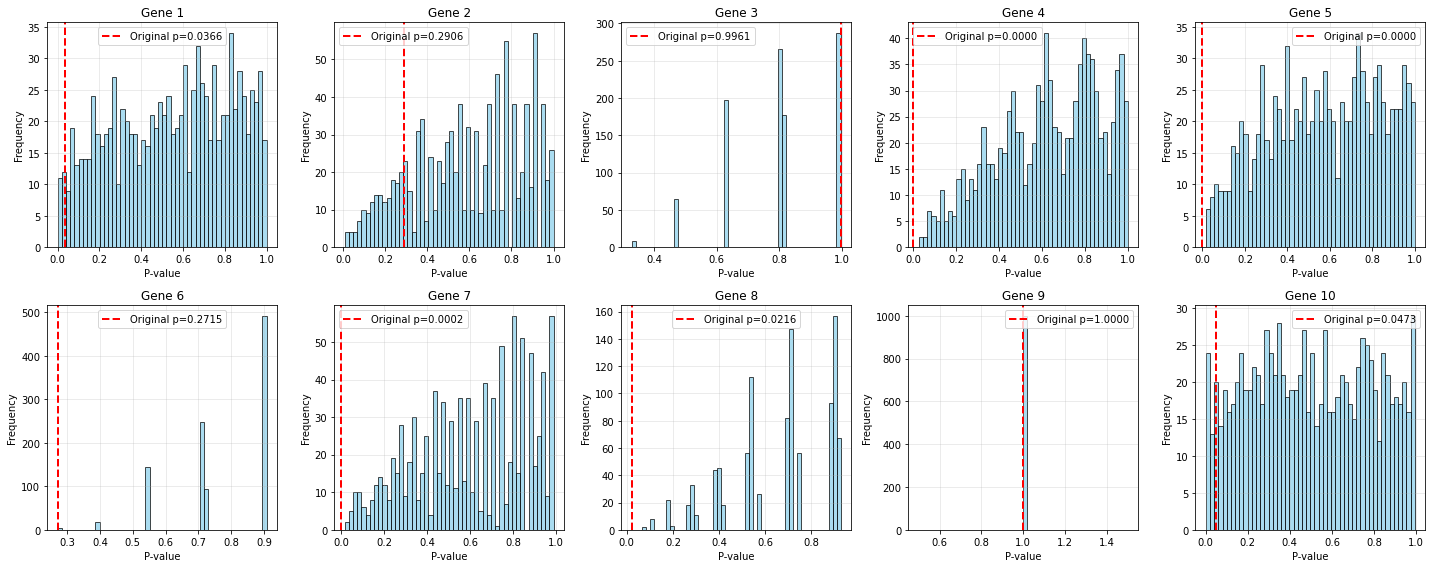

In [ ]:
# Create subplots for each gene's permutation p-value distribution
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for gene_idx in range(n_genes):
    gene_id = gene_idx + 1

    # Get permutation p-values for this gene
    perm_p_values = perm_ps_per_gene[gene_id]

    # Get original p-value for this gene
    original_p_value = wilcoxon_df[wilcoxon_df["gene"] == gene_id]["p_value"].values[0]

    # Plot histogram of permutation p-values
    axes[gene_idx].hist(
        perm_p_values, bins=50, alpha=0.7, color="skyblue", edgecolor="black"
    )

    # Plot vertical line for original p-value
    axes[gene_idx].axvline(
        original_p_value,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Original p={original_p_value:.4f}",
    )

    # Labels and title
    axes[gene_idx].set_xlabel("P-value")
    axes[gene_idx].set_ylabel("Frequency")
    axes[gene_idx].set_title(f"Gene {gene_id}")
    axes[gene_idx].legend()
    axes[gene_idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()